In [1]:
# 타이타닉 호 승객 생존 예측 미니 프로젝트 : 3. 머신러닝

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 한글깨짐 해결 코드, 원인 : 디폴트 영문글꼴 ==> 한글글꼴
import platform
import matplotlib.pyplot as plt
if platform.system() == 'Windows': # W 대문자
    plt.rcParams['font.family'] = 'Malgun Gothic' # 맑은 고딕
elif platform.system() == 'Darwin': # MacOS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 전처리가 완료된 파일 읽기
df = pd.read_csv('titanic_ok.csv')
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,sex2,title,title2
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,Miss,Miss
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",0,Master,Master
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,Miss,Miss
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,Mr,Mr
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",1,Mrs,Mrs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,1,Miss,Miss
1304,3,0,"Zabour, Miss. Thamine",female,21.9000,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,1,Miss,Miss
1305,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0,Mr,Mr
1306,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0,Mr,Mr


In [6]:
# 데이터(X)와 정답(y)를 준비한다.

In [7]:
# X를 얻는다.
# [ 선실등급, 성별, 나이, 형제_수, 부모_수, 운임 ]
x_cols = [ 'pclass', 'sex2', 'age', 'sibsp', 'parch', 'fare' ]
X = df[ x_cols ].values # numpy 배열로 리턴
X

array([[  1.    ,   1.    ,  29.    ,   0.    ,   0.    , 211.3375],
       [  1.    ,   0.    ,   0.9167,   1.    ,   2.    , 151.55  ],
       [  1.    ,   1.    ,   2.    ,   1.    ,   2.    , 151.55  ],
       ...,
       [  3.    ,   0.    ,  26.5   ,   0.    ,   0.    ,   7.225 ],
       [  3.    ,   0.    ,  27.    ,   0.    ,   0.    ,   7.225 ],
       [  3.    ,   0.    ,  29.    ,   0.    ,   0.    ,   7.875 ]])

In [8]:
# y를 얻는다.
y = df['survived'].values
y

array([1, 1, 0, ..., 0, 0, 0])

In [9]:
# ML 코딩 5단계
# 1. 훈련 데이터와 테스트 데이터를 얻는다.
# 2. ML 알고리즘 선택
# 3. 훈련 : 집에서 공부, model.fit(...)
# 4. 평가 : 학교에서 시험, model.score(...)
# 5. 새로운 데이터로 예측, model.predict(...)

In [10]:
# 1. 훈련 데이터와 테스트 데이터를 얻는다.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)

In [13]:
# 2. ML 알고리즘 선택

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [15]:
model = DecisionTreeClassifier() # 붕어빵 = 틀()

In [16]:
# 3. 훈련 : 집에서 공부

In [17]:
model.fit(X_train, y_train) # 비유 : 홍길동.공부해(문제지, 정답지), 주어.동사(목적어)

DecisionTreeClassifier()

In [18]:
# 4. 평가 : 학교에서 시험

In [19]:
print("훈련 점수:", model.score(X_train, y_train))
print("테스트 점수:", model.score(X_test, y_test))
# 97.1 - 74.8 ==> 23점(갭이 크면 overfitting)

훈련 점수: 0.9719626168224299
테스트 점수: 0.7480916030534351


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=7)
model = DecisionTreeClassifier(max_depth=6) # 튜닝
model.fit(X_train, y_train)
print("훈련 점수:", model.score(X_train, y_train))
print("테스트 점수:", model.score(X_test, y_test))
# 튜닝 전(overfitting)             ==> 튜닝 후
# 훈련 점수: 0.9719626168224299    ==> 0.8394222599830077
# 테스트 점수: 0.7480916030534351  ==> 0.8320610687022901
# 97 - 74 ==> 23점                 ==> 83.9 - 83.2 ==> 0.7

훈련 점수: 0.8394222599830077
테스트 점수: 0.8320610687022901


In [21]:
# 5. 새로운 데이터로 예측

In [22]:
# 디카프리오는 살 수 있었나?
# [[ 3등실, 남:0, 나이:19살, 형제:0, 부모:0, 운임:9달러 ]]
dicaprio = [[ 3, 0, 19, 0, 0, 9 ]]
result = model.predict_proba(dicaprio)
print(result) # [[0.88944724 0.11055276]] ==> [[ 사망확률 생존확률 ]]
print(f"생존확률:{result[0][1]*100:.2f}%")

[[0.88944724 0.11055276]]
생존확률:11.06%


In [23]:
# 여주인공 윈슬릿은?
# [[ 1등실, 여:1, 나이:17살, 형제:1, 부모:2, 운임:100달러 ]]
winslet = [[ 1, 1, 17, 1, 2, 100 ]]
result = model.predict_proba(winslet)
print(result) # [[0.00787402 0.99212598]] ==> [[ 사망확률 생존확률 ]]
print(f"생존확률:{result[0][1]*100:.2f}%")

[[0.00787402 0.99212598]]
생존확률:99.21%


In [24]:
from sklearn.tree import plot_tree

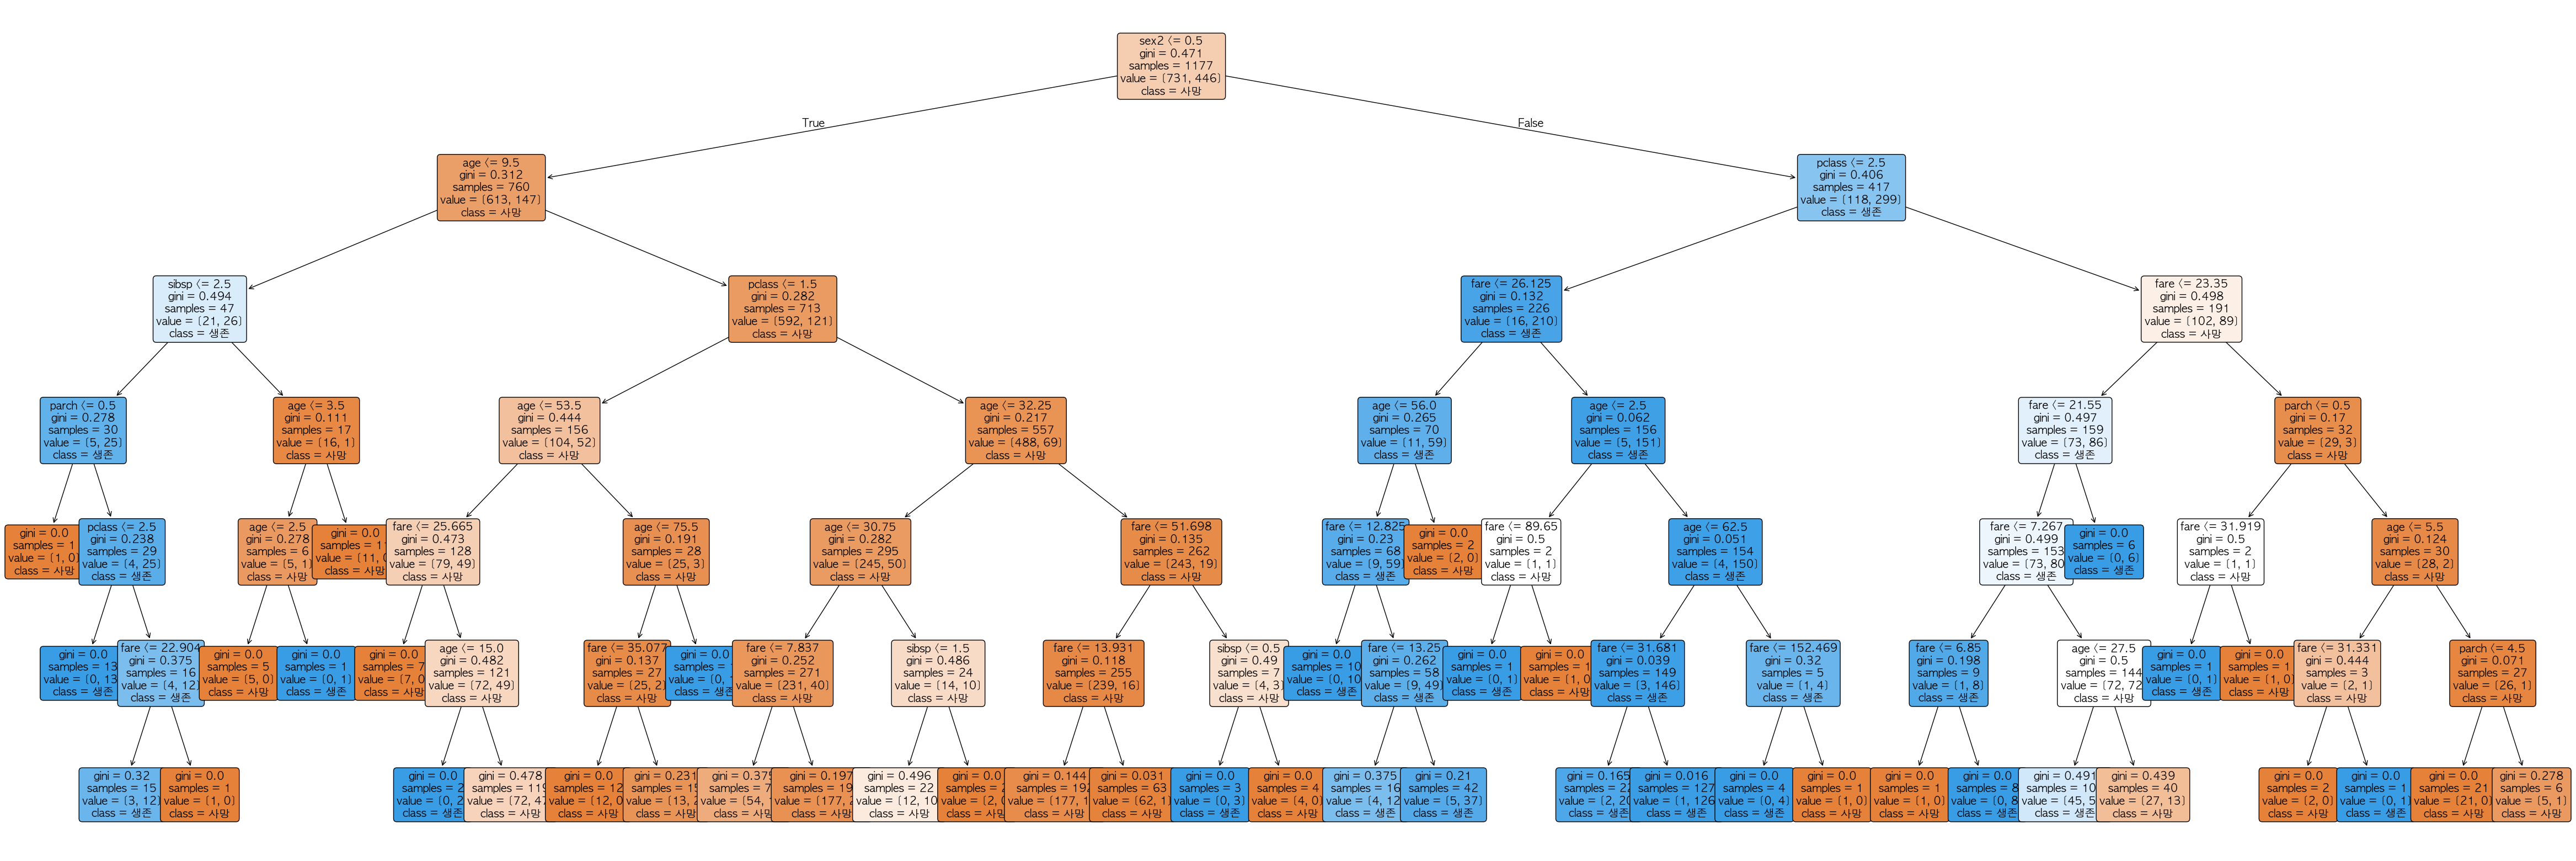

In [25]:
plt.figure(figsize=(60,20))
plot_tree(model, feature_names=x_cols, class_names=['사망','생존'],
         filled=True, rounded=True, fontsize=14)
plt.savefig('tree1.png')
plt.show()

In [26]:
# 중요도 확인
print(x_cols)
print(model.feature_importances_)

['pclass', 'sex2', 'age', 'sibsp', 'parch', 'fare']
[0.19217672 0.50652603 0.12086745 0.05902454 0.00823454 0.11317073]


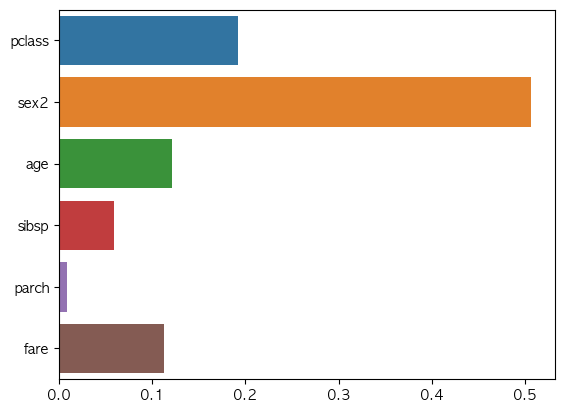

In [27]:
sns.barplot(x=model.feature_importances_, y=x_cols, palette='tab10')
plt.show()

In [28]:
f_imp = pd.Series(model.feature_importances_, index=x_cols).sort_values(ascending=False)
f_imp

sex2      0.506526
pclass    0.192177
age       0.120867
fare      0.113171
sibsp     0.059025
parch     0.008235
dtype: float64

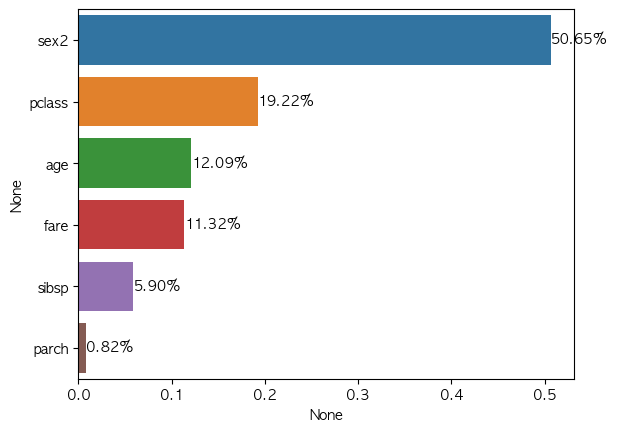

In [29]:
ax = sns.barplot(x=f_imp, y=f_imp.index, palette='tab10')
for bars in ax.containers:
    ax.bar_label(bars, fmt="{:.2%}")
plt.show()

In [30]:
# end